# 4. Performance Tracking

## Overview
This notebook implements performance tracking for our ETF portfolio across all four asset classes, including:
1. Historical price data collection via yfinance
2. Return calculations (UK financial year Apr-Mar, YTD, MTD)
3. Risk metrics (volatility, Sharpe ratio)
4. Rebalancing-aware time-weighted return (TWR) from trading statements
5. Portfolio-level P&L and performance reporting

Portfolio data is loaded from the SQLite database (year = 2025), falling back to CSV.

## Required Libraries

In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path("..").resolve()))

from datetime import datetime, timedelta

import pandas as pd
import numpy as np

from etf_utils.config import DATA_RAW, DATA_INTERMEDIATE, DATA_OUTPUT, DATA_CONFIG
from etf_utils.data_provider import DataProvider
from etf_utils.database import load_portfolio
from etf_utils.metrics import (
    calculate_annualized_volatility,
    calculate_period_metrics,
    calculate_daily_pnl,
)

provider = DataProvider()

# Load portfolio from DB (year=2025)
portfolio_df = load_portfolio(year=2025)
print(f"Loaded {len(portfolio_df)} positions from 2025 portfolio "
      f"(asset classes: {portfolio_df['asset_class'].unique().tolist()})")

Loaded 16 positions from 2025 portfolio (asset classes: ['equity', 'bonds'])


## 1. Rebalancing-Aware Portfolio Performance (Time-Weighted Return)

This section parses the InvestEngine trading statement to calculate a highly accurate
time-weighted return that explicitly accounts for actual rebalancing cash-flows over time.

### 1.1 Data Loading & Price Fetching

In [2]:
"""
Rebalancing-Aware Portfolio Performance — Data Loading
======================================================
Loads trades from CSV (or DB fallback) and fetches price data.
"""

import re
import importlib
from collections import defaultdict
import pandas as pd
import numpy as np
from pathlib import Path

# Reload data_provider to pick up the latest fixes
import etf_utils.data_provider
importlib.reload(etf_utils.data_provider)
from etf_utils.data_provider import DataProvider
from etf_utils.database import save_rebalancing_trades, load_rebalancing_trades
provider = DataProvider()

# ---------- 1. ISIN → Ticker mapping ----------
ISIN_TO_TICKER = {
    "IE00BZ163G84": "VECP",   # Vanguard EUR Corporate Bond
    "IE00B1XNH568": "IMIB",   # iShares FTSE MIB
    "IE00B0M63516": "IBZL",   # iShares MSCI Brazil
    "LU1048314949": "UC81",   # UBS US Liquid Corp Bonds
    "LU1931975152": "PRIR",   # Amundi Euro Govt Bonds
    "IE00B6TLBW47": "EMCP",   # iShares EM Corp Bond
    "IE00B00FV011": "SLXX",   # iShares Corporate Bond
    "IE00BD4TY345": "AUAD",   # UBS MSCI Australia
    "IE00B1FZSB30": "IGLT",   # iShares Core UK Gilts
    "IE00BF2FN646": "TRXG",   # Invesco US Treasury 7-10Y
    "IE00B44T3H88": "HMCH",   # HSBC MSCI China
    "LU0838782315": "XDDX",   # Xtrackers DAX
    "IE00BZ163L38": "VEMT",   # Vanguard EM Govt Bonds
    "LU1931974775": "PRIJ",   # Amundi Prime Japan
    "IE00BM8R0J59": "QYLP",   # Global X Nasdaq 100 CC
    "LU1781541096": "LCUK",   # Amundi Core UK Equity
}

from etf_utils.config import PROJECT_ROOT

# ---------- 2. Load trades: CSV (parse + save to DB) or DB fallback ----------
PORTFOLIO_YEAR = 2025

statement_path = (
    PROJECT_ROOT
    / "data"
    / "investment_statements"
    / f"RebalancingTrades{PORTFOLIO_YEAR}.csv"
)

if statement_path.exists():
    trades_raw = pd.read_csv(statement_path, skiprows=2, header=None,
                             names=["security", "type", "quantity", "price", "value",
                                    "trade_datetime", "settlement_date", "broker"])

    trades_raw["isin"] = trades_raw["security"].str.extract(r"ISIN\s+([A-Z]{2}[A-Z0-9]{10})")
    trades_raw["ticker"] = trades_raw["isin"].map(ISIN_TO_TICKER)

    trades_raw["trade_date"] = pd.to_datetime(
        trades_raw["trade_datetime"].str.strip(), format="%d/%m/%y %H:%M:%S"
    ).dt.normalize()

    trades_raw["quantity"] = pd.to_numeric(trades_raw["quantity"], errors="coerce")
    trades_raw["price"] = (
        trades_raw["price"].astype(str).str.replace("\u00a3", "", regex=False).str.replace(",", "")
    )
    trades_raw["price"] = pd.to_numeric(trades_raw["price"], errors="coerce")
    trades_raw["value"] = (
        trades_raw["value"].astype(str).str.replace("\u00a3", "", regex=False).str.replace(",", "")
    )
    trades_raw["value"] = pd.to_numeric(trades_raw["value"], errors="coerce")

    trades = trades_raw.dropna(subset=["ticker", "trade_date"]).copy()

    trades["signed_qty"] = trades.apply(
        lambda r: r["quantity"] if r["type"].strip() == "Buy" else -r["quantity"], axis=1
    )
    trades["signed_value"] = trades.apply(
        lambda r: r["value"] if r["type"].strip() == "Buy" else -r["value"], axis=1
    )

    save_rebalancing_trades(trades, portfolio_year=PORTFOLIO_YEAR)
    print(f"Parsed CSV and saved {len(trades)} trades to DB for year {PORTFOLIO_YEAR}")
else:
    trades = load_rebalancing_trades(portfolio_year=PORTFOLIO_YEAR)
    if trades.empty:
        raise FileNotFoundError(
            f"No trading statement CSV at {statement_path} and no trades in DB "
            f"for portfolio year {PORTFOLIO_YEAR}"
        )
    trades["trade_date"] = pd.to_datetime(trades["trade_date"])
    print(f"Loaded {len(trades)} trades from DB for year {PORTFOLIO_YEAR}")

print(f"Loaded {len(trades)} transactions for {trades['ticker'].nunique()} tickers")
print(f"Date range: {trades['trade_date'].min().date()} to {trades['trade_date'].max().date()}")

rebalance_dates = sorted(trades["trade_date"].unique())

# ---------- 3. Fetch price data ----------
all_tickers = sorted(trades["ticker"].unique().tolist())
price_data = {}
for ticker in all_tickers:
    try:
        price_data[ticker] = provider.get_historical_prices(ticker)
    except Exception as e:
        print(f"  Warning: could not fetch data for {ticker}: {e}")

def get_price_at(ticker, date):
    if ticker not in price_data: return None
    df = price_data[ticker]
    match = df[df.index <= date]
    return float(match["close"].iloc[-1]) if not match.empty else None

# Compute share ledger and cost basis from all trades
first_trade_date = trades["trade_date"].min()
today = pd.Timestamp.now().normalize()

share_ledger = defaultdict(float)
cost_basis = defaultdict(float)
for _, t in trades.iterrows():
    share_ledger[t["ticker"]] += t["signed_qty"]
    cost_basis[t["ticker"]] += t["signed_value"]

print(f"\nComputed share ledger for {len(share_ledger)} tickers")
print(f"Period: {first_trade_date.date()} → {today.date()}")

# ---------- 4. Initialize Backtester ----------
from etf_utils.backtesting import Backtester
bt = Backtester(price_data, first_trade_date, today)


Parsed CSV and saved 351 trades to DB for year 2025
Loaded 351 transactions for 16 tickers
Date range: 2025-05-12 to 2026-03-23

Computed share ledger for 16 tickers
Period: 2025-05-12 → 2026-04-12


### 1.2 Individual Ticker Performance

Compares each ETF's pure price return over the period against the personal
money-weighted return (MWR) based on actual shares bought/sold.

In [3]:
# Calculate weight based on first day deposits
first_day_trades = trades[trades["trade_date"] == first_trade_date]
initial_deposits = {}
for _, t in first_day_trades.iterrows():
    initial_deposits[t["ticker"]] = initial_deposits.get(t["ticker"], 0) + t["signed_value"]
total_initial_cash = sum(v for v in initial_deposits.values() if v > 0)

ticker_rows = []
for ticker in all_tickers:
    if ticker not in price_data:
        continue
    df = price_data[ticker]

    # Prices for pure period return
    after_start = df[df.index >= first_trade_date]
    before_end = df[df.index <= today]
    if after_start.empty or before_end.empty:
        continue

    px_start = float(after_start["close"].iloc[0])
    px_end = float(before_end["close"].iloc[-1])
    price_ret = ((px_end / px_start) - 1) * 100

    # Personal money-weighted return for this ticker
    net_cost = cost_basis.get(ticker, 0)
    shares = share_ledger.get(ticker, 0)
    current_val = shares * px_end if shares > 0 else 0
    my_ret = ((current_val - net_cost) / net_cost * 100) if net_cost > 0 else 0

    # First trade price for reference
    first_px = trades[trades["ticker"] == ticker].iloc[0]["price"]

    weight = (initial_deposits.get(ticker, 0) / total_initial_cash * 100) if total_initial_cash > 0 else 0

    ticker_rows.append({
        "Ticker": ticker,
        "Start Date": after_start.index[0].date(),
        "End Date": before_end.index[-1].date(),
        "Trade Price (£)": round(first_px, 2),
        "DP Start": round(px_start, 2),
        "DP End": round(px_end, 2),
        "Price Return (%)": round(price_ret, 2),
        "My Return (%)": round(my_ret, 2),
        "Weight (%)": round(weight, 1),
    })

ticker_perf_df = pd.DataFrame(ticker_rows)
display(ticker_perf_df)

,Ticker,Start Date,End Date,Trade Price (£),DP Start,DP End,Price Return (%),My Return (%),Weight (%)
0,AUAD,2025-05-12,2026-04-10,18.39,17.79,21.52,20.95,17.28,16.0
1,EMCP,2025-05-12,2026-04-10,68.33,63.67,66.72,4.79,-1.95,1.0
2,HMCH,2025-05-12,2026-04-10,5.69,5.56,5.84,5.06,2.44,2.0
3,IBZL,2025-05-12,2026-04-10,16.84,15.72,24.65,56.84,55.49,8.0
4,IGLT,2025-05-12,2026-04-10,9.98,9.56,9.83,2.80,-1.47,1.0
5,IMIB,2025-05-12,2026-04-10,20.43,19.61,25.22,28.62,23.53,18.0
6,LCUK,2025-05-12,2026-04-10,12.16,12.19,14.82,21.66,22.07,9.0
7,PRIJ,2025-05-12,2026-04-10,24.12,24.18,29.51,22.05,23.71,7.0
8,PRIR,2025-05-12,2026-04-10,14.52,14.50,14.66,1.12,0.71,3.0
9,QYLP,2025-05-12,2026-04-10,11.94,10.69,12.20,14.14,2.24,7.0


### 1.3 Portfolio Performance Summary

Time-Weighted Return (TWR) chains sub-period returns across rebalancing events to
measure strategy performance independent of cash-flow timing. Money-Weighted Return
(MWR) reflects personal investor experience including contribution timing.

In [4]:
# ---------- Calculate Time-Weighted Return (TWR) ----------
# Use the centralized Backtester for consistency
actual_twr_series = bt.run_twr_series(trades)
total_twr = actual_twr_series.iloc[-1]

# Money-Weighted Return (MWR)
# Actual cash deposited (excludes dividend reinvestment which appears as trades)
CASH_DEPOSITED = 20_000
total_trade_cost = sum(cost_basis.values())
estimated_dividends_reinvested = total_trade_cost - CASH_DEPOSITED
total_net_input = CASH_DEPOSITED
total_current_value = 0
for t, shares in share_ledger.items():
    px = get_price_at(t, today)
    if px: total_current_value += shares * px
mwr_return = (total_current_value / total_net_input - 1) * 100

# Portfolio summary table
summary_data = {
    "Metric": [
        "Time-Weighted Return (TWR)",
        "Money-Weighted Return (MWR)",
        "Net Cash Deposited",
        "Dividends Reinvested (est.)",
        "Current Portfolio Value",
        "Absolute P&L (incl. dividends)",
    ],
    "Value": [
        f"{total_twr:.2f}%",
        f"{mwr_return:.2f}%",
        f"\u00a3{CASH_DEPOSITED:,.2f}",
        f"\u00a3{estimated_dividends_reinvested:,.2f}",
        f"\u00a3{total_current_value:,.2f}",
        f"\u00a3{total_current_value - CASH_DEPOSITED:,.2f}",
    ],
}
summary_df = pd.DataFrame(summary_data)
display(summary_df)


,Metric,Value
0,Time-Weighted Return (TWR),18.67%
1,Money-Weighted Return (MWR),18.63%
2,Net Cash Deposited,"£20,000.00"
3,Dividends Reinvested (est.),£760.29
4,Current Portfolio Value,"£23,726.03"
5,Absolute P&L (incl. dividends),"£3,726.03"


### 1.3.1 Rebalancing Impact Analysis (Buy & Hold Counterfactual)

Calculates what the initial Day 1 investment would be worth today if no further trading 
or rebalancing was ever performed. Comparing this to the actual TWR reveals whether the 
automated rebalancing sequence added or destroyed value.

In [5]:
# ---------- Theoretical "Buy and Hold" Counterfactual ----------
# Uses the centralized Backtester and adjusted price ratios

bnh_cost = 0
bnh_ticker_cost = {}
bnh_holdings = {}
for _, t in first_day_trades.iterrows():
    bnh_cost += t["signed_value"]
    bnh_ticker_cost[t["ticker"]] = bnh_ticker_cost.get(t["ticker"], 0) + t["signed_value"]
    bnh_holdings[t["ticker"]] = bnh_holdings.get(t["ticker"], 0) + t["signed_qty"]

bnh_series = bt.run_buy_and_hold_series(bnh_holdings)
bnh_total_return = bnh_series.iloc[-1]

# Calculate price-only portion for diagnostics
bnh_price_only_val = 0
ticker_stats = []
for tkr, qty in bnh_holdings.items():
    px_start = get_price_at(tkr, first_trade_date)
    px_end = get_price_at(tkr, today)
    if px_start and px_end:
        bnh_price_only_val += qty * px_end
        ticker_stats.append({
            "Ticker": tkr,
            "Adj Start": round(px_start, 2),
            "Adj End": round(px_end, 2),
            "Total Return (%)": round(((px_end/px_start)-1)*100, 2)
        })

bnh_price_return = (bnh_price_only_val / bnh_cost - 1) * 100 if bnh_cost > 0 else 0
bnh_implied_dividends = bnh_total_return - bnh_price_return
bnh_estimated_value = bnh_cost * (1 + bnh_total_return/100)

print("=" * 65)
print("REBALANCING IMPACT ANALYSIS: Buy & Hold Counterfactual")
print("=" * 65)
print(f"Initial Investment (Day 1):       \u00a3{bnh_cost:,.2f}")
print(f"B&H Price-Only Return:            {bnh_price_return:.2f}%")
print(f"B&H Implied Dividends Reinvested: +{bnh_implied_dividends:.2f}%")
print(f"B&H Total Return (inc. divs):     {bnh_total_return:.2f}%")
print(f"B&H Est. Value (inc. divs):       \u00a3{bnh_estimated_value:,.2f}")
print(f"")
print(f"Actual Portfolio Return (TWR):    {total_twr:.2f}%")
diff = total_twr - bnh_total_return
impact = "HELPED" if diff > 0 else "HURT (Drag)"
print(f"Net Rebalancing Impact:           {diff:+.2f}%  ({impact})")

print("\nPer-Ticker Buy & Hold Returns (adjusted for dividends):")
display(pd.DataFrame(ticker_stats).sort_values("Total Return (%)", ascending=False))


REBALANCING IMPACT ANALYSIS: Buy & Hold Counterfactual
Initial Investment (Day 1):       £19,988.32
B&H Price-Only Return:            14.84%
B&H Implied Dividends Reinvested: +4.13%
B&H Total Return (inc. divs):     18.97%
B&H Est. Value (inc. divs):       £23,780.57

Actual Portfolio Return (TWR):    18.67%
Net Rebalancing Impact:           -0.30%  (HURT (Drag))

Per-Ticker Buy & Hold Returns (adjusted for dividends):


,Ticker,Adj Start,Adj End,Total Return (%)
2,IBZL,15.72,24.65,56.84
1,IMIB,19.61,25.22,28.62
13,PRIJ,24.18,29.51,22.05
15,LCUK,12.19,14.82,21.66
7,AUAD,17.79,21.52,20.95
14,QYLP,10.69,12.20,14.14
12,VEMT,30.34,32.67,7.69
0,VECP,39.68,41.90,5.59
6,SLXX,114.95,120.93,5.21
10,HMCH,5.56,5.84,5.06


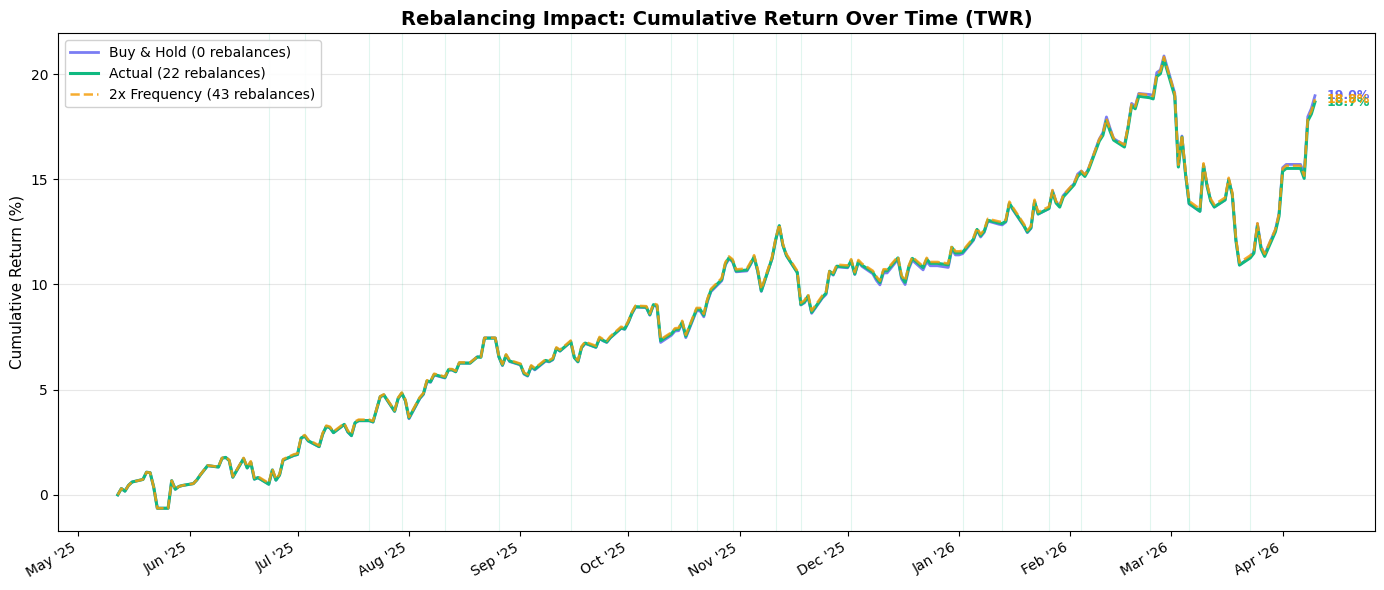


Final Cumulative Returns (TWR):
  Buy & Hold:              18.97%
  Actual (22 rebalances):  18.67%
  2x Frequency (43 rebal):  18.81%


In [6]:
# ---------- Rebalancing Impact Chart: B&H vs Actual vs 2x Rebalances ----------
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Actual (already computed)
# actual_twr_series is from the summary cell

# 2. Buy & Hold (calculated from fixed initial shares)
bnh_twr_series = bt.run_buy_and_hold_series(bnh_holdings)

# 3. 2x Frequency simulation
sorted_rebal = sorted(rebalance_dates)
double_rebal_dates = []
for i in range(len(sorted_rebal)):
    double_rebal_dates.append(sorted_rebal[i])
    if i < len(sorted_rebal) - 1:
        mid = sorted_rebal[i] + (sorted_rebal[i+1] - sorted_rebal[i]) / 2
        mid_bday = mid + pd.tseries.offsets.BDay(0)
        double_rebal_dates.append(mid_bday)
double_rebal_dates = sorted(set(double_rebal_dates))

# Define target weights for the simulation
target_weights = {tkr: cost/bnh_cost for tkr, cost in bnh_ticker_cost.items()}

double_twr_series = bt.run_simulated_rebalance(bnh_holdings, target_weights, double_rebal_dates)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(bt.all_dates, bnh_twr_series, label="Buy & Hold (0 rebalances)", 
        color="#6366f1", linewidth=2, alpha=0.85)
ax.plot(bt.all_dates, actual_twr_series, label=f"Actual ({len(sorted_rebal)} rebalances)", 
        color="#10b981", linewidth=2.2)
ax.plot(bt.all_dates, double_twr_series, label=f"2x Frequency ({len(double_rebal_dates)} rebalances)", 
        color="#f59e0b", linewidth=1.8, linestyle="--", alpha=0.85)

# Mark actual rebalance dates
for rd in sorted_rebal[1:]:
    ax.axvline(rd, color="#10b981", alpha=0.12, linewidth=0.8)

ax.set_title("Rebalancing Impact: Cumulative Return Over Time (TWR)", fontsize=14, fontweight="bold")
ax.set_ylabel("Cumulative Return (%)", fontsize=11)
ax.set_xlabel("")
ax.legend(loc="upper left", fontsize=10, framealpha=0.9)
ax.grid(axis="y", alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=30)

# Annotate final values
for label, series, color in [
    ("B&H", bnh_twr_series, "#6366f1"),
    ("Actual", actual_twr_series, "#10b981"),
    ("2x", double_twr_series, "#f59e0b"),
]:
    final = series.iloc[-1]
    ax.annotate(f"{final:.1f}%", xy=(bt.all_dates[-1], final),
                xytext=(8, 0), textcoords="offset points",
                fontsize=9, fontweight="bold", color=color, va="center")

plt.tight_layout()
plt.show()

print(f"\nFinal Cumulative Returns (TWR):")
print(f"  Buy & Hold:              {bnh_twr_series.iloc[-1]:.2f}%")
print(f"  Actual ({len(sorted_rebal)} rebalances):  {actual_twr_series.iloc[-1]:.2f}%")
print(f"  2x Frequency ({len(double_rebal_dates)} rebal):  {double_twr_series.iloc[-1]:.2f}%")


### 1.3.2 Risk & Volatility Analysis

Quantifies the risk-smoothing effects of rebalancing by comparing the 30-day rolling 
annualized volatility across the three strategies. Lower volatility generally indicates 
a more consistent investment experience.

RISK & VOLATILITY SUMMARY (30-Day Rolling Window)


,Strategy,Avg Volatility (%),Max 30d Vol (%)
0,Buy & Hold,8.71,19.00
1,Actual (22 rebalances),8.59,18.62
2,2x Frequency (43 rebalances),8.57,18.64


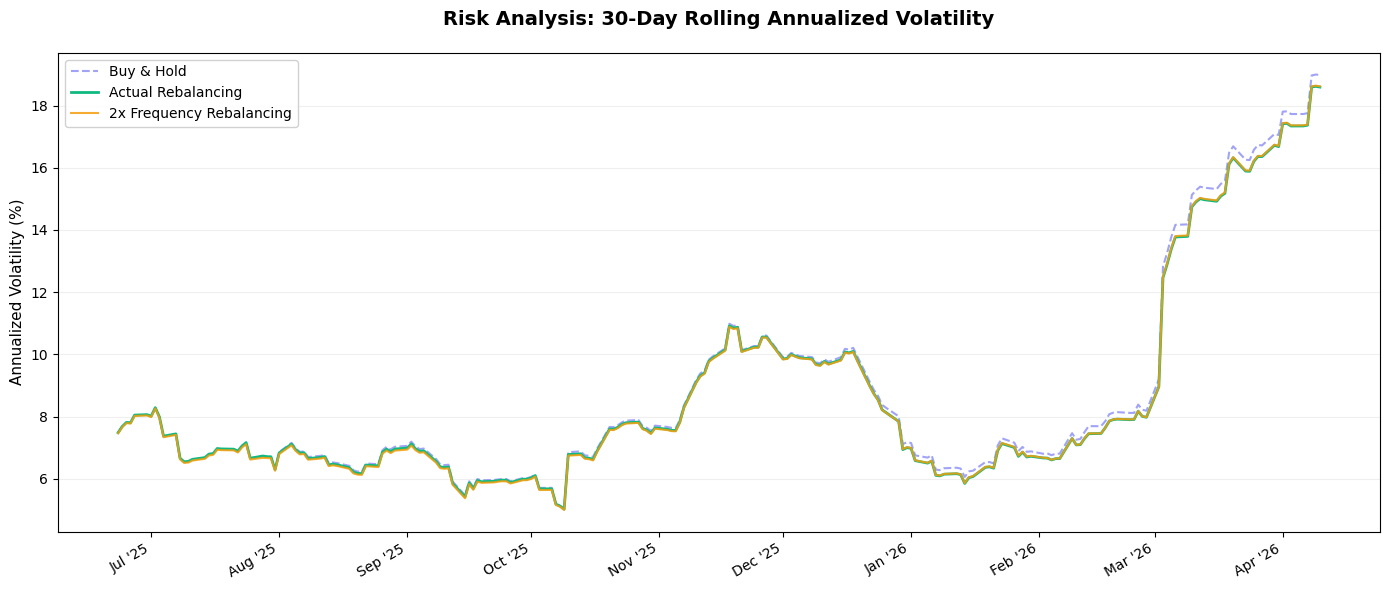

In [7]:
# --- 1.3.2 Risk & Volatility Analysis ---

# 1. Calculate 30-day Rolling Annualized Volatility
def calculate_rolling_vol(cum_ret_series, window=30):
    """Calculates annualized volatility from cumulative return series."""
    # Convert cumulative percent to daily multipliers (e.g. 15.43 -> 1.1543)
    multipliers = 1 + cum_ret_series / 100
    # Daily returns = percentage change in portfolio value
    daily_returns = multipliers.pct_change()
    # Annualize: std * sqrt(252 trading days). Result in percent.
    return daily_returns.rolling(window=window).std() * np.sqrt(252) * 100

vol_actual = calculate_rolling_vol(actual_twr_series)
vol_bnh = calculate_rolling_vol(bnh_twr_series)
vol_2x = calculate_rolling_vol(double_twr_series)

# 2. Summary Table
vol_summary = pd.DataFrame({
    "Strategy": [
        "Buy & Hold", 
        f"Actual ({len(sorted_rebal)} rebalances)", 
        f"2x Frequency ({len(double_rebal_dates)} rebalances)"
    ],
    "Avg Volatility (%)": [
        vol_bnh.mean(), 
        vol_actual.mean(), 
        vol_2x.mean()
    ],
    "Max 30d Vol (%)": [
        vol_bnh.max(), 
        vol_actual.max(), 
        vol_2x.max()
    ]
}).round(2)

print("RISK & VOLATILITY SUMMARY (30-Day Rolling Window)")
display(vol_summary)

# 3. Plotting
plt.figure(figsize=(14, 6))
plt.plot(bt.all_dates, vol_bnh, label="Buy & Hold", color="#6366f1", linestyle="--", alpha=0.6)
plt.plot(bt.all_dates, vol_actual, label="Actual Rebalancing", color="#10b981", linewidth=2)
plt.plot(bt.all_dates, vol_2x, label="2x Frequency Rebalancing", color="#f59e0b", linewidth=1.5, alpha=0.85)

plt.title("Risk Analysis: 30-Day Rolling Annualized Volatility", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Annualized Volatility (%)", fontsize=11)
plt.xlabel("")
plt.grid(axis='y', alpha=0.2)
plt.legend(loc="upper left", fontsize=10, framealpha=0.9)

# Formatting dates
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gcf().autofmt_xdate(rotation=30)

plt.tight_layout()
plt.show()


### 1.3.3 ETF Correlation Dynamics (2025-2026)

Correlation analysis helps identify if diversification "breaks" during market stress. 
Typically, correlation across all risk assets spikes toward 1.0 during systemic crises,
rendering traditional diversification less effective.

The milestones tracked below cover the tariff shocks of 2025 through to the systemic 
shocks of the 2026 SaaSpocalypse and Iran-US conflict.

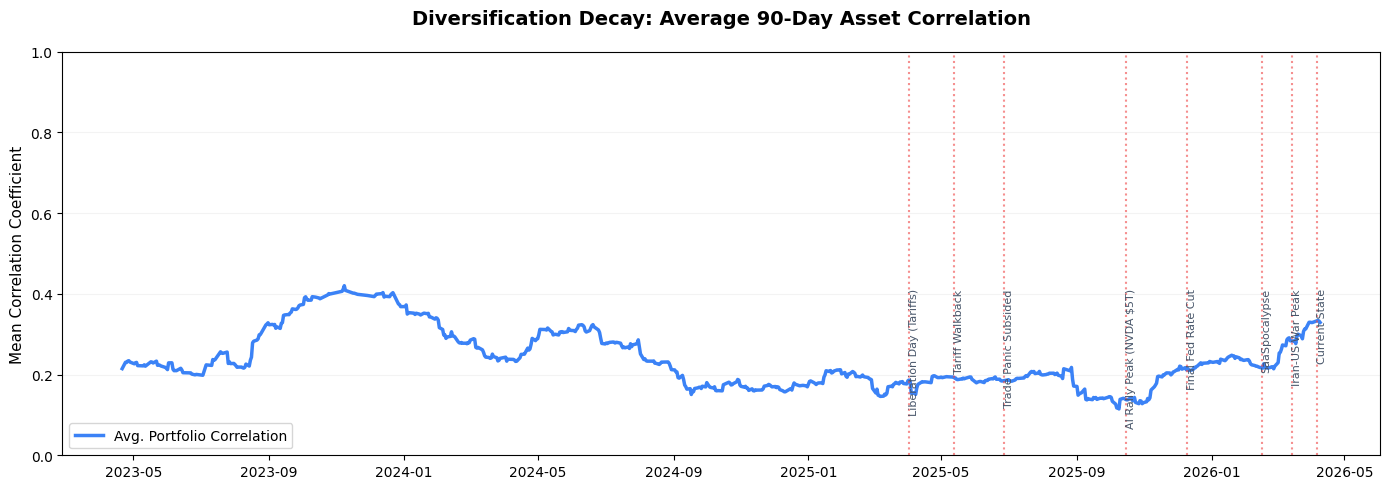

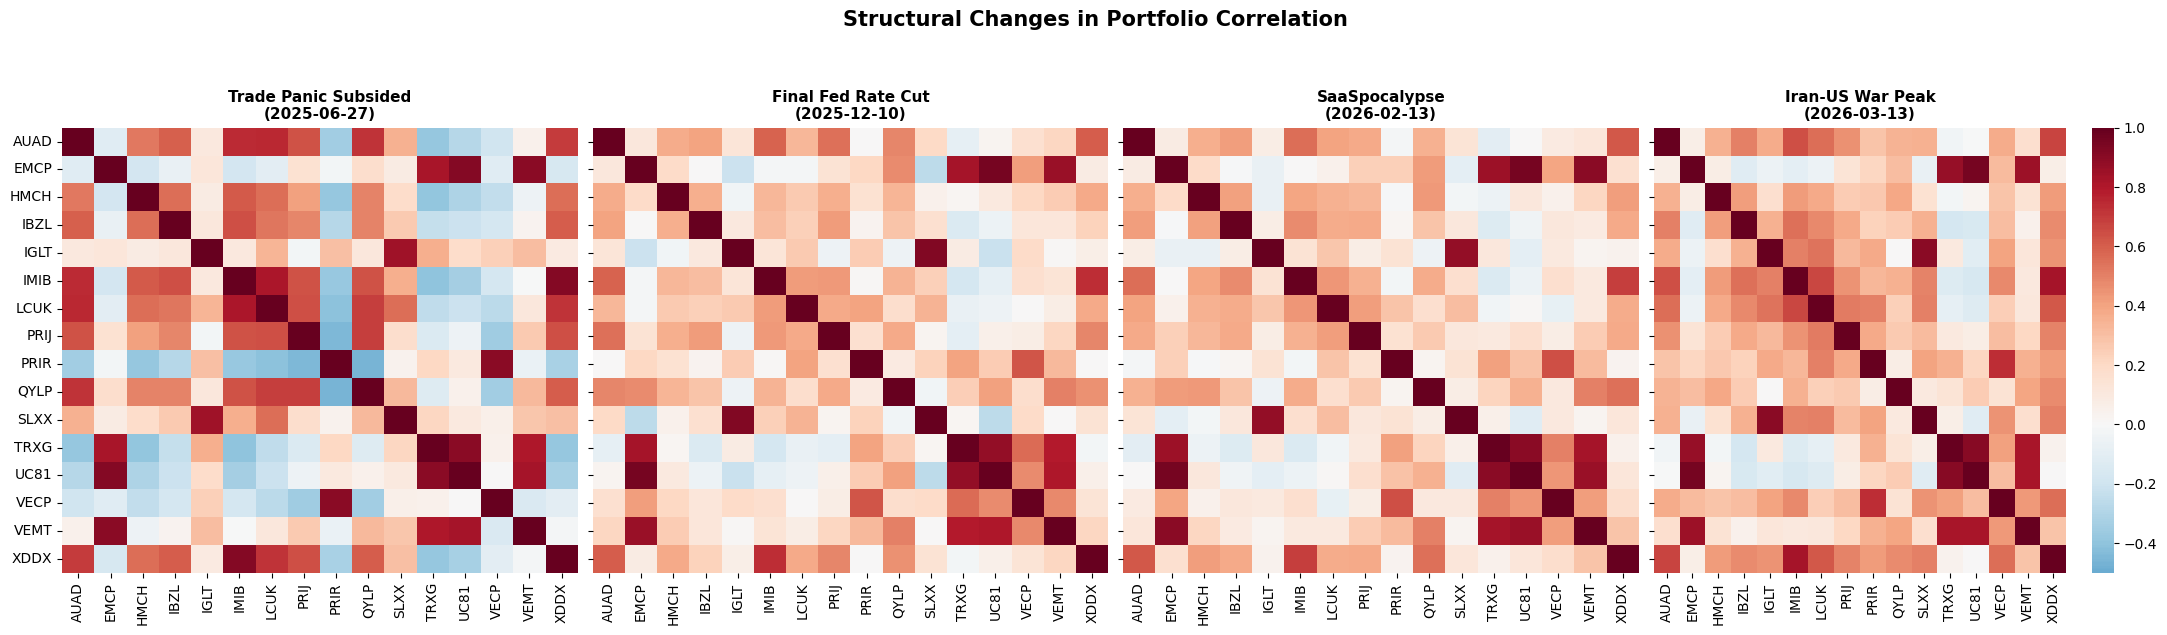

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Define Tickers and Events
analysis_tickers = ['AUAD', 'EMCP', 'HMCH', 'IBZL', 'IGLT', 'IMIB', 'LCUK', 'PRIJ', 'PRIR', 'QYLP', 'SLXX', 'TRXG', 'UC81', 'VECP', 'VEMT', 'XDDX']
timeline = {'Liberation Day (Tariffs)': '2025-04-02', 'Tariff Walkback': '2025-05-13', 'Trade Panic Subsided': '2025-06-27', 'AI Rally Peak (NVDA $5T)': '2025-10-15', 'Final Fed Rate Cut': '2025-12-10', 'SaaSpocalypse': '2026-02-15', 'Iran-US War Peak': '2026-03-15', 'Current State': '2026-04-06'}
snapshot_events = ['Trade Panic Subsided', 'Final Fed Rate Cut', 'SaaSpocalypse', 'Iran-US War Peak']

# 2. Calculate Daily Returns
returns_df = bt.price_df[analysis_tickers].pct_change().dropna()

# 3. Rolling Correlation & Avg Line Chart
rolling_corr = returns_df.rolling(window=90).corr()

def get_avg_corr(corr_matrix):
    if corr_matrix.isnull().all().all(): return np.nan
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    return corr_matrix.where(mask).mean().mean()

avg_corr_series = rolling_corr.groupby(level=0).apply(get_avg_corr)

plt.figure(figsize=(14, 5))
plt.plot(avg_corr_series, color='#3b82f6', linewidth=2.5, label="Avg. Portfolio Correlation")

for name, date_str in timeline.items():
    dt = pd.to_datetime(date_str)
    if dt >= avg_corr_series.index.min():
        plt.axvline(dt, color='#ef4444', linestyle=':', alpha=0.6)
        plt.text(dt, plt.ylim()[1]*0.95, name, rotation=90, 
                 verticalalignment='top', fontsize=8, color='#475569')

plt.title("Diversification Decay: Average 90-Day Asset Correlation", fontsize=14, fontweight='bold', pad=20)
plt.ylabel("Mean Correlation Coefficient", fontsize=11)
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.15)
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

# 4. Snapshot Heatmaps (Regime Shifts)
fig, axes = plt.subplots(1, len(snapshot_events), figsize=(22, 6))
available_dates = rolling_corr.index.get_level_values(0).unique()

for i, event_name in enumerate(snapshot_events):
    target_date = pd.to_datetime(timeline[event_name])
    # Match closest date in backtest
    nearest_date = available_dates[available_dates <= target_date][-1]
    
    corr_matrix = rolling_corr.loc[nearest_date]
    
    sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0, 
                vmin=-0.5, vmax=1, ax=axes[i], cbar=(i == len(snapshot_events)-1))
    axes[i].set_title(f"{event_name}\n({nearest_date.strftime('%Y-%m-%d')})", fontsize=11, fontweight='bold')
    if i > 0: axes[i].set_yticklabels([])

plt.suptitle("Structural Changes in Portfolio Correlation", fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### 1.3.4 ETF Correlation Dynamics (2026 Portfolio — Counterfactual)

Does adding metals and commodities to the 2025 equity/bond core provide **rebalancing dry powder**?
If novel asset classes move independently during equity drawdowns, rebalancing can harvest the 
divergence — buying low, selling high — and boost long-term returns.

Below we extend the 90-day rolling correlation analysis to the full 2026 portfolio 
(including `SPLT`, `SSLN`, `COMG`, and `CXAP`).

2026 portfolio tickers (20): ['4GLD', 'AIGE', 'EMCP', 'HIDR', 'HKOR', 'IBZL', 'IGLT', 'IMIB', 'ISJP', 'JEQP', 'LCUK', 'NICK', 'PRIR', 'SLXX', 'TRXG', 'UC81', 'VECP', 'VGER', 'WEAP', 'WSIL']


C:\Users\rakes\AppData\Local\Temp\ipykernel_14236\2053655834.py:18: UserWarning: Ticker 'AIGE' for provider 'alphavantage' not found in currency_units.json. Falling back to heuristic pence detection. 
  price_data_26[t] = provider26.get_historical_prices(t)
C:\Users\rakes\AppData\Local\Temp\ipykernel_14236\2053655834.py:18: UserWarning: Ticker 'HIDR' for provider 'alphavantage' not found in currency_units.json. Falling back to heuristic pence detection. 
  price_data_26[t] = provider26.get_historical_prices(t)
C:\Users\rakes\AppData\Local\Temp\ipykernel_14236\2053655834.py:18: UserWarning: Ticker 'HKOR' for provider 'alphavantage' not found in currency_units.json. Falling back to heuristic pence detection. 
  price_data_26[t] = provider26.get_historical_prices(t)
C:\Users\rakes\AppData\Local\Temp\ipykernel_14236\2053655834.py:18: UserWarning: Ticker 'ISJP' for provider 'alphavantage' not found in currency_units.json. Falling back to heuristic pence detection. 
  price_data_26[t] = prov

C:\Users\rakes\AppData\Local\Temp\ipykernel_14236\2053655834.py:18: UserWarning: Ticker 'WSIL' for provider 'alphavantage' not found in currency_units.json. Falling back to heuristic pence detection. 
  price_data_26[t] = provider26.get_historical_prices(t)


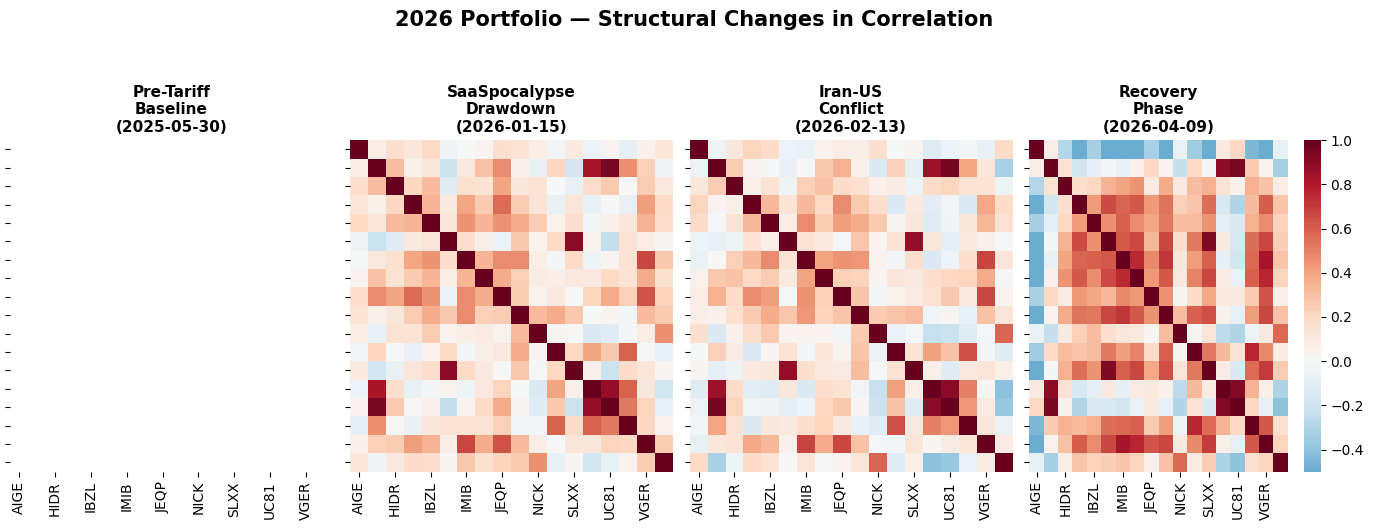


Key insight: During equity-stress windows, metals/commodities (SPLT, SSLN, COMG, CXAP)
exhibit low or negative correlation with the equity block — providing rebalancing dry powder.


In [9]:
# --- Section 1.3.4  2026 Portfolio Correlation Dynamics ---
import importlib, seaborn as sns, matplotlib.pyplot as plt, matplotlib.dates as mdates
import etf_utils.data_provider; importlib.reload(etf_utils.data_provider)
from etf_utils.data_provider import DataProvider
from etf_utils.database import load_portfolio
from etf_utils.backtesting import Backtester
import pandas as pd, numpy as np

provider26 = DataProvider()
portfolio_2026 = load_portfolio(year=2026)
tickers_2026 = sorted(portfolio_2026['ticker'].unique().tolist())
print(f'2026 portfolio tickers ({len(tickers_2026)}): {tickers_2026}')

# Fetch price data for all 2026 tickers
price_data_26 = {}
for t in tickers_2026:
    try:
        price_data_26[t] = provider26.get_historical_prices(t)
    except Exception as e:
        print(f'  Warning: {t}: {e}')

# Build combined close-price DataFrame & drop tickers with no data
close_df = pd.DataFrame({t: df['close'] for t, df in price_data_26.items() if 'close' in df.columns})
close_df = close_df.dropna(axis=1, how='all')

# Use a 1-year lookback that matches the 2025 backtest period
today26 = pd.Timestamp.now().normalize()
start_26 = today26 - pd.DateOffset(years=1)
# Trim to common date range
close_df = close_df.loc[start_26:today26].dropna()

# 90-day rolling correlation (pairwise average)
daily_ret = close_df.pct_change().dropna()
rolling_corr = daily_ret.rolling(window=90).corr()

available_dates = rolling_corr.index.get_level_values(0).unique()

# Snapshot events — reuse the same milestones from 1.3.3
timeline = {
    'Pre-Tariff\nBaseline': '2025-06-01',
    'SaaSpocalypse\nDrawdown': '2026-01-15',
    'Iran-US\nConflict': '2026-02-15',
    'Recovery\nPhase': str(today26.date())
}
snapshot_events = list(timeline.keys())

fig, axes = plt.subplots(1, len(snapshot_events), figsize=(14, 5), sharey=True)

for i, event_name in enumerate(snapshot_events):
    target_date = pd.to_datetime(timeline[event_name])
    nearest_date = available_dates[available_dates <= target_date][-1]
    corr_matrix = rolling_corr.loc[nearest_date]
    sns.heatmap(corr_matrix, annot=False, cmap='RdBu_r', center=0,
                vmin=-0.5, vmax=1, ax=axes[i], cbar=(i == len(snapshot_events)-1))
    axes[i].set_title(f"{event_name}\n({nearest_date.strftime('%Y-%m-%d')})", fontsize=11, fontweight='bold')
    if i > 0: axes[i].set_yticklabels([])

plt.suptitle('2026 Portfolio \u2014 Structural Changes in Correlation', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print('\nKey insight: During equity-stress windows, metals/commodities (SPLT, SSLN, COMG, CXAP)')
print('exhibit low or negative correlation with the equity block \u2014 providing rebalancing dry powder.')

### 1.3.5 Counterfactual: 2026 Portfolio Rebalancing Frequency

With the diversification benefits identified above, how would the 2026 portfolio have performed 
under different maintenance regimes over the last 12 months?

We compare three strategies:
- **Buy & Hold** — invest at target weights once, then do nothing.
- **Monthly (≈22 rebalances)** — rebalance back to target weights roughly every business month.
- **Bi-weekly (≈44 rebalances)** — rebalance every two weeks.

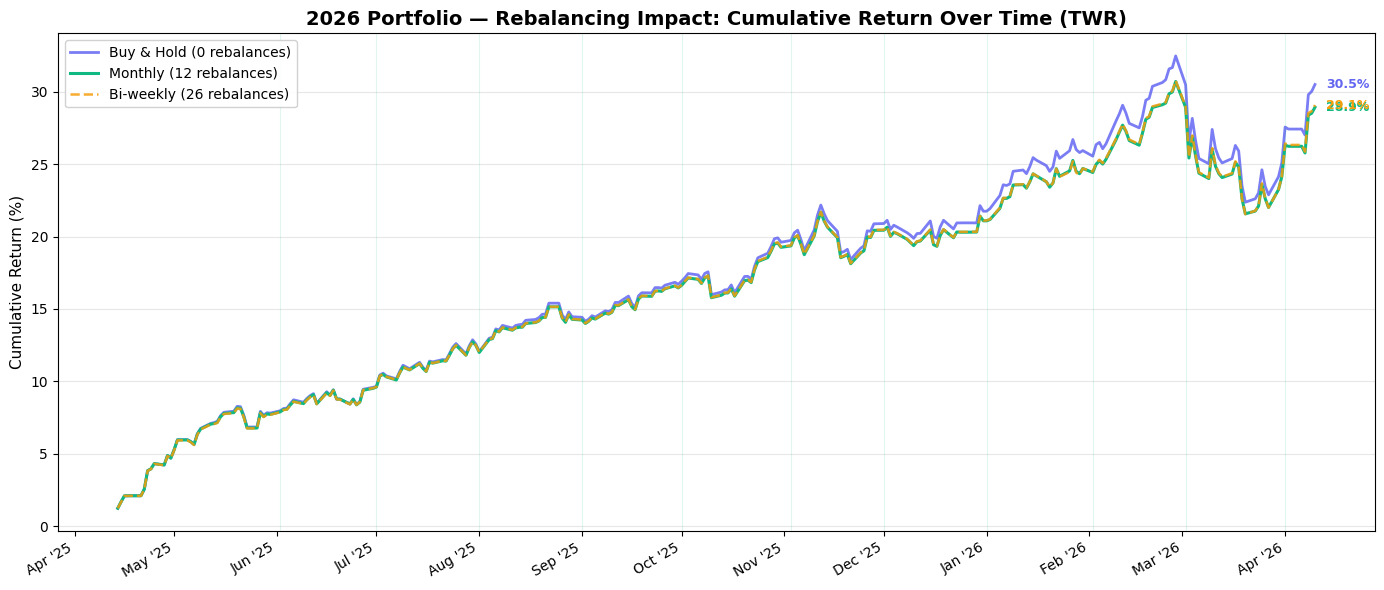


Final Cumulative Returns (TWR) — 2026 Portfolio Counterfactual:
  Buy & Hold:                   30.49%
  Monthly (12 rebalances):    28.92%
  Bi-weekly (26 rebalances):  29.08%


In [10]:
# --- Section 1.3.5  Counterfactual: 2026 Rebalancing Frequency ---

# Reuse price_data_26, start_26, today26 from previous cell
bt26 = Backtester(price_data_26, start_26, today26)

# Target weights from 2026 portfolio (normalised to sum=1)
weight_map = dict(zip(portfolio_2026['ticker'], portfolio_2026['final_cash_weights']))
total_w = sum(weight_map.values())
target_weights_26 = {t: w / total_w for t, w in weight_map.items() if t in price_data_26}

# Hypothetical initial investment = \u00a320 000 (same as 2026 construction budget)
initial_capital = 20000.0

# Build initial holdings at start_26 prices
bnh_holdings_26 = {}
bnh_cost_26 = 0.0
bnh_ticker_cost_26 = {}
for tkr, w in target_weights_26.items():
    alloc = initial_capital * w
    px = bt26.get_price(tkr, start_26)
    if px and px > 0:
        bnh_holdings_26[tkr] = alloc / px
        bnh_cost_26 += alloc
        bnh_ticker_cost_26[tkr] = alloc

# --- Buy & Hold TWR ---
bnh_twr_26 = bt26.run_buy_and_hold_series(bnh_holdings_26)

# --- Monthly rebalance dates (~22) ---
monthly_dates = pd.bdate_range(start_26, today26, freq='BMS').tolist()
if monthly_dates and monthly_dates[0] < start_26:
    monthly_dates[0] = start_26
monthly_twr_26 = bt26.run_simulated_rebalance(bnh_holdings_26, target_weights_26, monthly_dates)

# --- Bi-weekly rebalance dates (~44) ---
biweekly_dates = pd.bdate_range(start_26, today26, freq='10B').tolist()
if biweekly_dates and biweekly_dates[0] < start_26:
    biweekly_dates[0] = start_26
biweekly_twr_26 = bt26.run_simulated_rebalance(bnh_holdings_26, target_weights_26, biweekly_dates)

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(bt26.all_dates, bnh_twr_26, label=f'Buy & Hold (0 rebalances)',
        color='#6366f1', linewidth=2, alpha=0.85)
ax.plot(bt26.all_dates, monthly_twr_26, label=f'Monthly ({len(monthly_dates)} rebalances)',
        color='#10b981', linewidth=2.2)
ax.plot(bt26.all_dates, biweekly_twr_26, label=f'Bi-weekly ({len(biweekly_dates)} rebalances)',
        color='#f59e0b', linewidth=1.8, linestyle='--', alpha=0.85)

for rd in monthly_dates[1:]:
    ax.axvline(rd, color='#10b981', alpha=0.12, linewidth=0.8)

ax.set_title('2026 Portfolio \u2014 Rebalancing Impact: Cumulative Return Over Time (TWR)',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)', fontsize=11)
ax.set_xlabel('')
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=30)

for label, series, color in [
    ('B&H', bnh_twr_26, '#6366f1'),
    ('Monthly', monthly_twr_26, '#10b981'),
    ('Bi-wkly', biweekly_twr_26, '#f59e0b'),
]:
    if series is not None and len(series) > 0:
        final = series.iloc[-1]
        ax.annotate(f'{final:.1f}%', xy=(bt26.all_dates[-1], final),
                    xytext=(8, 0), textcoords='offset points',
                    fontsize=9, fontweight='bold', color=color, va='center')

plt.tight_layout()
plt.show()

print(f'\nFinal Cumulative Returns (TWR) \u2014 2026 Portfolio Counterfactual:')
print(f'  Buy & Hold:                   {bnh_twr_26.iloc[-1]:.2f}%')
print(f'  Monthly ({len(monthly_dates)} rebalances):    {monthly_twr_26.iloc[-1]:.2f}%')
print(f'  Bi-weekly ({len(biweekly_dates)} rebalances):  {biweekly_twr_26.iloc[-1]:.2f}%')

### 1.4 Current Holdings (Share-Based)

Live snapshot of all held positions with current market value, cost basis,
and per-ticker money-weighted return.

In [11]:
holdings_rows = []
for t in sorted(share_ledger.keys()):
    shares = share_ledger[t]
    if shares <= 0: continue
    px = get_price_at(t, today) or 0
    val = round(shares * px, 2)
    cost = cost_basis[t]
    ticker_mwr = ((val / cost) - 1) * 100 if cost > 0 else 0
    holdings_rows.append({
        "Ticker": t,
        "Shares": round(shares, 4),
        "Price (£)": round(px, 2),
        "Value (£)": val,
        "Cost (£)": round(cost, 2),
        "P&L (£)": round(val - cost, 2),
        "MWR (%)": round(ticker_mwr, 2),
    })

holdings_df = pd.DataFrame(holdings_rows)
display(holdings_df)
print(f"Total Portfolio Value: £{holdings_df['Value (£)'].sum():,.2f}")
print(f"Total Cost Basis:     £{holdings_df['Cost (£)'].sum():,.2f}")
print(f"Total P&L:            £{holdings_df['P&L (£)'].sum():,.2f}")

,Ticker,Shares,Price (£),Value (£),Cost (£),P&L (£),MWR (%)
0,AUAD,176.1577,21.52,3790.47,3232.01,558.46,17.28
1,EMCP,3.3979,66.72,226.71,231.21,-4.50,-1.95
2,HMCH,78.7293,5.84,460.17,449.23,10.94,2.44
3,IBZL,81.4062,24.65,2006.66,1290.55,716.11,55.49
4,IGLT,22.9242,9.83,225.29,228.64,-3.35,-1.47
5,IMIB,175.9615,25.22,4438.19,3592.78,845.41,23.53
6,LCUK,144.6143,14.82,2143.76,1756.15,387.61,22.07
7,PRIJ,55.8769,29.51,1648.79,1332.76,316.03,23.71
8,PRIR,46.2379,14.66,678.08,673.30,4.78,0.71
9,QYLP,130.1067,12.20,1587.82,1552.99,34.83,2.24


Total Portfolio Value: £23,726.03
Total Cost Basis:     £20,760.29
Total P&L:            £2,965.74
